In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt

import warnings
warnings.simplefilter(action="ignore")

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/lyst-csvs/lyst_hottest_brands_2019_q1.csv
/kaggle/input/lyst-csvs/lyst_hottest_brands_2018_q4.csv
/kaggle/input/lyst-csvs/lyst_hottest_brands_2018_q3.csv
/kaggle/input/lyst-csvs/lyst_hottest_brands_2021_q2.csv
/kaggle/input/lyst-csvs/lyst_hottest_brands_2024_q2.csv
/kaggle/input/lyst-csvs/lyst_hottest_brands_2020_q3.csv
/kaggle/input/lyst-csvs/lyst_hottest_brands_2024_q4.csv
/kaggle/input/lyst-csvs/lyst_hottest_brands_2022_q3.csv
/kaggle/input/lyst-csvs/lyst_hottest_brands_2019_q3.csv
/kaggle/input/lyst-csvs/lyst_hottest_brands_2020_q1.csv
/kaggle/input/lyst-csvs/lyst_hottest_brands_2024_q1.csv
/kaggle/input/lyst-csvs/lyst_hottest_brands_2022_q2.csv
/kaggle/input/lyst-csvs/lyst_hottest_brands_2021_q3.csv
/kaggle/input/lyst-csvs/lyst_hottest_brands_2020_q4.csv
/kaggle/input/lyst-csvs/lyst_hottest_brands_2023_q2.csv
/kaggle/input/lyst-csvs/lyst_hottest_brands_2023_q3.csv
/kaggle/input/lyst-csvs/lyst_hottest_brands_2021_q4.csv
/kaggle/input/lyst-csvs/lyst_hottest_brands_2019

In [3]:
filenames = os.listdir('/kaggle/input/lyst-csvs')

lysts = pd.concat([pd.read_csv('/kaggle/input/lyst-csvs/' + file) for file in filenames], ignore_index=True)
lysts

,Rank,Brand,Year,Quarter
0,1,off-white,2019,q1
1,2,gucci,2019,q1
2,3,balenciaga,2019,q1
3,4,valentino,2019,q1
4,5,fendi,2019,q1
...,...,...,...,...
495,16,loewe,2021,q1
496,17,givenchy,2021,q1
497,18,jacquemus,2021,q1
498,19,balmain,2021,q1


In [4]:
unique_brands1 = lysts['Brand'].unique()
unique_brands1

array(['off-white', 'gucci', 'balenciaga', 'valentino', 'fendi', 'prada',
       'stone island', 'versace', 'vetements', 'saint laurent', 'nike',
       'burberry', 'moncler', 'givenchy', 'dolce & gabbana', 'yeezy',
       'balmain', 'palm angels', 'adidas', 'alexander mcqueen', 'dior',
       'louis vuitton', 'bottega veneta', 'off-white™', 'loewe',
       'jacquemus', 'rick owens', 'miu miu', 'skims', 'new balance',
       'the row', 'alaïa', 'jw anderson', 'coach', 'fear of god',
       'marine serre', 'ugg', 'cos', 'ralph lauren', 'chloé', 'totême',
       'diesel', 'moschino', 'raf simons', 'thom browne',
       'dolce &\xa0gabbana', 'ferragamo', 'acne studios', 'canada goose',
       'dr martens', 'toteme', 'victoria beckham', 'd&g'], dtype=object)

In [5]:
len(unique_brands1)

53

In [6]:
def dolce_and_gabbana(brand_name):
    if brand_name == 'd&g' or brand_name == 'dolce &\xa0gabbana' or brand_name == 'dolce & gabbana':
        return 'dolce and gabbana'
    else:
        return brand_name

def off_white(brand_name):
    if brand_name == 'off-white™'or brand_name == 'off-white':
        return 'off-white'
    else:
        return brand_name

def toteme(brand_name):
    if brand_name == 'toteme' or brand_name == 'totême':
        return 'totême'
    else:
        return brand_name

In [7]:
lysts['Brand'] = lysts['Brand'].apply(dolce_and_gabbana)

In [8]:
lysts['Brand'] = lysts['Brand'].apply(off_white)

In [9]:
lysts['Brand'] = lysts['Brand'].apply(toteme)

In [10]:
unique_brands2 = lysts['Brand'].unique()
unique_brands2

array(['off-white', 'gucci', 'balenciaga', 'valentino', 'fendi', 'prada',
       'stone island', 'versace', 'vetements', 'saint laurent', 'nike',
       'burberry', 'moncler', 'givenchy', 'dolce and gabbana', 'yeezy',
       'balmain', 'palm angels', 'adidas', 'alexander mcqueen', 'dior',
       'louis vuitton', 'bottega veneta', 'loewe', 'jacquemus',
       'rick owens', 'miu miu', 'skims', 'new balance', 'the row',
       'alaïa', 'jw anderson', 'coach', 'fear of god', 'marine serre',
       'ugg', 'cos', 'ralph lauren', 'chloé', 'totême', 'diesel',
       'moschino', 'raf simons', 'thom browne', 'ferragamo',
       'acne studios', 'canada goose', 'dr martens', 'victoria beckham'],
      dtype=object)

In [11]:
len(unique_brands2)

49

In [12]:
lysts.to_csv('lysts_for_tab.csv', index=False)

In [20]:
hottest_brands = lysts.groupby('Brand')['Rank'].mean().sort_values(ascending=True).to_frame().head()
hottest_brands

,Rank
Brand,
prada,3.720000
gucci,4.384615
miu miu,4.615385
balenciaga,6.423077
off-white,6.500000


In [14]:
lysts_sorted = lysts.sort_values(['Year', 'Quarter'])
lysts_sorted

,Rank,Brand,Year,Quarter
30,1,off-white,2018,q3
31,2,gucci,2018,q3
32,3,balenciaga,2018,q3
33,4,nike,2018,q3
34,5,prada,2018,q3
...,...,...,...,...
115,16,valentino,2024,q4
116,17,cos,2024,q4
117,18,ralph lauren,2024,q4
118,19,chloé,2024,q4


In [15]:
lysts_pivoted = lysts_sorted.pivot(index='Brand', columns=['Year', 'Quarter'], values='Rank')
lysts_pivoted

Year               2018        2019                    2020                    \
Quarter              q3    q4    q1    q2    q3    q4    q1    q2    q3    q4   
Brand                                                                           
acne studios        NaN   NaN   NaN   NaN   NaN  17.0   NaN   NaN   NaN   NaN   
adidas              NaN   NaN  19.0  16.0   NaN   NaN   NaN  13.0  17.0  18.0   
alaïa               NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
alexander mcqueen   NaN   NaN  20.0   NaN  17.0   NaN   NaN  15.0  14.0  14.0   
balenciaga          3.0   3.0   3.0   3.0   2.0   3.0   2.0   4.0   5.0   2.0   
balmain             NaN   NaN  17.0  20.0  19.0   NaN   NaN  17.0  16.0  16.0   
bottega veneta      NaN   NaN   NaN   NaN  16.0  14.0  13.0  10.0   9.0   7.0   
burberry            NaN  10.0  12.0  12.0   8.0  10.0  11.0   8.0  12.0  12.0   
canada goose        NaN   NaN   NaN   NaN   NaN  18.0   NaN   NaN   NaN   NaN   
chloé               NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
coach               NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
cos                 NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
diesel              NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
dior                NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
dolce and gabbana   NaN   NaN  15.0  13.0  15.0   NaN   NaN   NaN   NaN   NaN   
dr martens          NaN   NaN   NaN   NaN   NaN  19.0   NaN   NaN   NaN   NaN   
fear of god         NaN   NaN   NaN   NaN   NaN   NaN   NaN  20.0  19.0  20.0   
fendi               9.0   5.0   5.0   7.0   7.0   6.0   7.0   9.0   6.0  10.0   
ferragamo           NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
givenchy            NaN   NaN  14.0  14.0  13.0  13.0  14.0   NaN  18.0  17.0   
gucci               2.0   1.0   2.0   1.0   3.0   2.0   4.0   3.0   1.0   1.0   
jacquemus           NaN   NaN   NaN   NaN   NaN   NaN  15.0  11.0  11.0  13.0   
jw anderson         NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
loewe               NaN   NaN   NaN   NaN  20.0  20.0  18.0  16.0  15.0  15.0   
louis vuitton       NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
marine serre        NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  20.0   NaN   
miu miu             NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
moncler             NaN   4.0  13.0  17.0  14.0   4.0   6.0  14.0  13.0   3.0   
moschino            NaN   NaN   NaN  18.0  18.0   NaN   NaN   NaN   NaN   NaN   
new balance         NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
nike                4.0   NaN  11.0   9.0  12.0  12.0   3.0   1.0   3.0  11.0   
off-white           1.0   2.0   1.0   2.0   1.0   1.0   1.0   2.0   2.0   4.0   
palm angels         NaN   NaN  18.0  15.0   NaN   NaN   NaN   NaN   NaN   NaN   
prada               5.0   NaN   6.0   5.0   5.0   7.0   5.0   5.0   4.0   5.0   
raf simons          NaN   NaN   NaN   NaN   NaN   NaN  17.0   NaN   NaN   NaN   
ralph lauren        NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
rick owens          NaN   NaN   NaN   NaN   NaN   NaN  20.0   NaN   NaN   NaN   
saint laurent       NaN   NaN  10.0  10.0   9.0   9.0   9.0   6.0   8.0   6.0   
skims               NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
stone island        NaN   7.0   7.0   8.0  11.0  11.0  12.0  19.0   NaN  19.0   
the row             NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
thom browne         NaN   NaN   NaN   NaN   NaN   NaN  19.0   NaN   NaN   NaN   
totême              NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
ugg                 NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
valentino          10.0   9.0   4.0   4.0   6.0   8.0   8.0  12.0  10.0   9.0   
versace             6.0   6.0   8.0   6.0   4.0   5.0  10.0   7.0   7.0   8.0   
vetements           8.0   8.0  

In [24]:
hottest_list = list(hottest_brands.index)
hottest_list

['prada', 'gucci', 'miu miu', 'balenciaga', 'off-white']

In [30]:
hottest_pivot = lysts_pivoted.loc[hottest_list]
hottest_pivot

Year       2018      2019                2020                 ...  2022        \
Quarter      q3   q4   q1   q2   q3   q4   q1   q2   q3   q4  ...    q3    q4   
Brand                                                         ...               
prada       5.0  NaN  6.0  5.0  5.0  7.0  5.0  5.0  4.0  5.0  ...   2.0   1.0   
gucci       2.0  1.0  2.0  1.0  3.0  2.0  4.0  3.0  1.0  1.0  ...   1.0   2.0   
miu miu     NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...   5.0   4.0   
balenciaga  3.0  3.0  3.0  3.0  2.0  3.0  2.0  4.0  5.0  2.0  ...   4.0  11.0   
off-white   1.0  2.0  1.0  2.0  1.0  1.0  1.0  2.0  2.0  4.0  ...  20.0   NaN   

Year        2023                    2024                    
Quarter       q1    q2    q3    q4    q1    q2    q3    q4  
Brand                                                       
prada        1.0   2.0   3.0   1.0   2.0   3.0   3.0   3.0  
gucci        9.0   9.0  12.0  11.0  11.0  10.0   8.0  12.0  
miu miu      2.0   4.0   1.0   2.0   1.0   2.0   1.0   1.0  
balenciaga  18.0  16.0  14.0  12.0   8.0   7.0  17.0  15.0  
off-white    NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  

[5 rows x 26 columns]

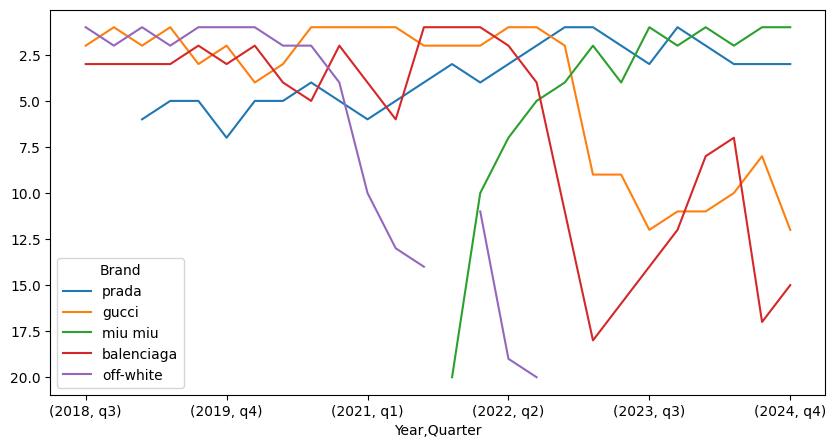

In [52]:
import matplotlib as plt

viz = hottest_pivot.T.plot(figsize=(10, 5))

viz.invert_yaxis()

**prada**: consistent (they've been around awhile)

**gucci**: dips at the start of 2023 due to a change in creative director

**miu miu**: enters the lyst after a standout SS'22 show (I remember watching during my English class senior year of high school)

**balenciaga**: dips drastically near the end of 2022 due to an advertising scandal

**off-white**: disappears after 2022 because of the passing of virgil abloh, the brand's original creative director